# Lab 2: Forward Kinematics (worked solutions)

Companion to `ForwardKinematicsTemplate.ipynb` and `pdfs/Forward_Kinematics.pdf`.
Same layout as the Lab 1 solutions: the code cells are the template's own cells with the blanks filled in. Around them:
**Task**, **How it works** (each piece of syntax and maths, line by line) and short **Example** blocks (code with its
output, written as text, so there is nothing extra to run).

**Two parts:**
- Tasks 1–17 are pure Python (DH model vs URDF model). They run on the laptop and the outputs below are real.
- Tasks 18–29 need the ROS 2 controller `mycobot_control`, which runs on the robot's Pi and drives the **real arm**.
  Those cells were **not executed** here (no outputs). Every cell that moves the robot is off by default
  (`send_motion = False` / `publish_ros2 = False`), and a person switches it on after the checks.

**URDF:** the notebook loads the course file `mycobot_280_gazebo.urdf` from the notebook's folder. It is not in the
repo yet, so Task 9 falls back (via `labpaths.urdf_path()`) to `mycobot_280_pi.urdf` and prints a note. The fallback is
almost certainly the same robot geometry as the course file (with it, Lab 5 reproduces the calibration stored in the
controller's launch file to six digits), so the numbers below should be the ones you get with the course file too.
Check once the file is available. **Important for this lab:** the differences between the handout's DH table and the
URDF (a few millimetres, Tasks 12–17) are a property of those two descriptions, not of the fallback.


## Setup

In [1]:
%matplotlib widget
import numpy as np
from scipy.spatial.transform import Rotation as R
from spatialmath import SE3
from spatialmath.base import *
import roboticstoolbox as rtb
from roboticstoolbox import DHRobot, RevoluteDH

np.set_printoptions(precision=4, suppress=True)

**How it works**
- `from spatialmath.base import *` imports **all** public functions of that module (`transl`, `trotx`, `tr2rpy`, …).
  Handy in a notebook; in real code prefer explicit names, so you can see where each name comes from.
- `DHRobot` / `RevoluteDH` are the Robotics Toolbox classes for a robot described by a DH table.
- `np.set_printoptions(precision=4, suppress=True)` prints 4 decimals and writes tiny numbers such as `6.1e-17` as `0.`.
  It only changes how arrays are printed (not in the template; added here to keep the matrices readable).

---
## Task 1: DH parameters
**Task:** the classical (standard) DH parameters of the myCobot 280 from the handout, with `dh_alpha` for the
twist angles.

Handout, Table 1 and Table 2 ($\theta_i = q_i + \text{offset}_i$):

| i | $d_i$ [m] | $a_i$ [m] | $\alpha_i$ [rad] | offset$_i$ [rad] |
|---|---|---|---|---|
| 1 | 0.13122 | 0 | $\pi/2$ | 0 |
| 2 | 0 | −0.1104 | 0 | $-\pi/2$ |
| 3 | 0 | −0.096 | 0 | 0 |
| 4 | 0.0634 | 0 | $\pi/2$ | $-\pi/2$ |
| 5 | 0.07505 | 0 | $-\pi/2$ | $\pi/2$ |
| 6 | 0.0456 | 0 | 0 | 0 |

In [2]:
dh_d      = np.array([0.13122, 0.0, 0.0, 0.0634, 0.07505, 0.0456])        # m
dh_a      = np.array([0.0, -0.1104, -0.096, 0.0, 0.0, 0.0])               # m
dh_alpha  = np.array([np.pi/2, 0.0, 0.0, np.pi/2, -np.pi/2, 0.0])         # rad
dh_offset = np.array([0.0, -np.pi/2, 0.0, -np.pi/2, np.pi/2, 0.0])        # rad
print(dh_alpha)

[ 1.5708  0.      0.      1.5708 -1.5708  0.    ]


**How it works**
- One NumPy array per DH column, index `i-1` = joint `i`. Keeping the columns separate makes the later
  `RevoluteDH(d=dh_d[i], ...)` calls readable.
- **Meaning of the four parameters** (standard DH, transform from frame $i-1$ to frame $i$):
  - $\theta_i$: rotation about $z_{i-1}$ (the joint variable for a revolute joint, plus its offset)
  - $d_i$: translation along $z_{i-1}$
  - $a_i$: translation along the new $x_i$ (length of the common normal)
  - $\alpha_i$: rotation about the new $x_i$ (twist between $z_{i-1}$ and $z_i$)
- $\alpha_1 = \pi/2$: the base joint axis is vertical, joint 2's axis is horizontal → a 90° twist.
  $\alpha_2 = \alpha_3 = 0$: joints 2, 3, 4 are parallel (the "elbow plane").
- The **offsets** make $q = 0$ the robot's own zero pose (arm straight up). They are not DH parameters in the strict
  sense, they just shift where each joint counts from.

---
## Task 2: Homogeneous transformation of the first link
**Task:** with the Lab 1 building blocks, build the transform of joint/link 1 at $\theta_1 = \pi/4$.

$$ A_1 = T_z(d_1)\,R_z(\theta_1)\,T_x(a_1)\,R_x(\alpha_1) $$

In [3]:
a = dh_a[0]
alpha = dh_alpha[0]
d = dh_d[0]
theta = np.pi/4 + dh_offset[0]

trvecx = np.array([a, 0, 0])
trvecz = np.array([0, 0, d])

tformtx = transl(trvecx)
tformtz = transl(trvecz)
tformrotx = trotx(alpha)
tformrotz = trotz(theta)

shoulderlink = tformtz @ tformrotz @ tformtx @ tformrotx
print(shoulderlink)

[[ 0.7071 -0.      0.7071  0.    ]
 [ 0.7071  0.     -0.7071  0.    ]
 [ 0.      1.      0.      0.1312]
 [ 0.      0.      0.      1.    ]]


**How it works**
- Exactly Lab 1, Task 8 with the myCobot's numbers: current-frame composition, so the four matrices are
  post-multiplied in the order $T_z, R_z, T_x, R_x$.
- `transl([x, y, z])`, `trotx(angle)`, `trotz(angle)` (spatialmath) each return a 4×4 NumPy array.
- Reading the result: the last column `[0, 0, 0.1312]` says frame 1 sits 0.131 m above the base. The third column of the
  rotation block, `[0.707, -0.707, 0]`, is the new z-axis: it lies in the horizontal plane. That is joint 2's rotation
  axis, turned 45° about the vertical because $\theta_1 = \pi/4$.

**Check:** the Robotics Toolbox computes the same matrix from the DH link (`.A(q)` = link transform at joint value q):

```python
link1_check = RevoluteDH(d=dh_d[0], a=dh_a[0], alpha=dh_alpha[0], offset=dh_offset[0])
print(np.allclose(link1_check.A(np.pi/4).A, shoulderlink))
```

Output:
```text
True
```


- `link1_check.A(np.pi/4)` returns an `SE3` object; the second `.A` gives its NumPy array. (Two different things
  both called `A`: a method on the link, an attribute on `SE3`.)

---
## Manual FK model (Tasks 3–8)
## Task 3: Base transform

In [5]:
base = SE3()

**How it works**
- `SE3()` with no arguments is the identity transform. The DH frame 0 is placed at the URDF's `g_base` frame, so no
  base offset is needed. (If frame 0 were higher, you would write e.g. `SE3(0, 0, 0.05)` or `SE3.Tz(0.05)`.)

**Example: the identity transform**

```python
print(base)
```

Output:
```text
   1         0         0         0         
   0         1         0         0         
   0         0         1         0         
   0         0         0         1         
```


---
## Task 4: First revolute link and a one-link robot

In [7]:
link1 = RevoluteDH(d=dh_d[0], a=dh_a[0], alpha=dh_alpha[0], offset=dh_offset[0], name='joint1')
manual_links = [link1]
manual_robot = DHRobot(manual_links, base=base, name="myCobot280_manual")

**How it works**
- `RevoluteDH(d=..., a=..., alpha=..., offset=...)` creates one standard-DH link whose joint variable is $\theta$.
  All arguments are keyword arguments; any you leave out default to 0.
- `name='joint1'` is passed through to the link and shows up in plots and printouts.
- `DHRobot(list_of_links, base=..., name=...)` assembles the chain.

---
## Task 5: Verify the structure

In [8]:
print(manual_robot)

DHRobot: myCobot280_manual, 1 joints (R), dynamics, standard DH parameters
┌─────┬────────┬────┬───────┐
│ θⱼ  │   dⱼ   │ aⱼ │  ⍺ⱼ   │
├─────┼────────┼────┼───────┤
│  q1 │ 0.1312 │  0 │ 90.0° │
└─────┴────────┴────┴───────┘



- The table lists $\theta_j$ (as `q1` + offset), $d_j$, $a_j$, $\alpha_j$ per joint. Check them against Task 1.

---
## Task 6: All six links

In [9]:
link2 = RevoluteDH(d=dh_d[1], a=dh_a[1], alpha=dh_alpha[1], offset=dh_offset[1], name='joint2')
link3 = RevoluteDH(d=dh_d[2], a=dh_a[2], alpha=dh_alpha[2], offset=dh_offset[2], name='joint3')
link4 = RevoluteDH(d=dh_d[3], a=dh_a[3], alpha=dh_alpha[3], offset=dh_offset[3], name='joint4')
link5 = RevoluteDH(d=dh_d[4], a=dh_a[4], alpha=dh_alpha[4], offset=dh_offset[4], name='joint5')
link6 = RevoluteDH(d=dh_d[5], a=dh_a[5], alpha=dh_alpha[5], offset=dh_offset[5], name='joint6')

manual_links = [link1, link2, link3, link4, link5, link6]
manual_robot = DHRobot(manual_links, base=base, name="myCobot280_manual")
print(manual_robot)

DHRobot: myCobot280_manual, 6 joints (RRRRRR), dynamics, standard DH parameters
┌───────────┬─────────┬─────────┬────────┐
│    θⱼ     │   dⱼ    │   aⱼ    │   ⍺ⱼ   │
├───────────┼─────────┼─────────┼────────┤
│  q1       │  0.1312 │       0 │  90.0° │
│  q2 - 90° │       0 │ -0.1104 │   0.0° │
│  q3       │       0 │  -0.096 │   0.0° │
│  q4 - 90° │  0.0634 │       0 │  90.0° │
│  q5 + 90° │ 0.07505 │       0 │ -90.0° │
│  q6       │  0.0456 │       0 │   0.0° │
└───────────┴─────────┴─────────┴────────┘



**How it works**
- Same pattern six times. A shorter, equivalent way is a **list comprehension**:

  ```python
  manual_links = [RevoluteDH(d=dh_d[i], a=dh_a[i], alpha=dh_alpha[i], offset=dh_offset[i], name=f'joint{i+1}')
                  for i in range(6)]
  ```
  `[expr for i in range(6)]` builds a list by evaluating `expr` for i = 0…5.
- `q2 - 90°` in the printout is joint 2 with its −π/2 offset.

---
## Task 7: Manual end-effector (tool) frame

In [10]:
manual_tool = SE3(np.eye(4))

manual_robot = DHRobot(manual_links, base=base, tool=manual_tool, name="myCobot280_manual")

**How it works**
- `SE3(np.eye(4))` builds an SE3 from a 4×4 array; the identity means "tool frame = last DH frame (frame 6)".
- FK of a `DHRobot` is always $T = \text{base} \cdot A_1(q_1) \cdots A_6(q_6) \cdot \text{tool}$.
  `base` and `tool` are constant transforms at the two ends of the chain.

---
## Task 8: Verify the structure

In [11]:
print(manual_robot)

DHRobot: myCobot280_manual, 6 joints (RRRRRR), dynamics, standard DH parameters
┌───────────┬─────────┬─────────┬────────┐
│    θⱼ     │   dⱼ    │   aⱼ    │   ⍺ⱼ   │
├───────────┼─────────┼─────────┼────────┤
│  q1       │  0.1312 │       0 │  90.0° │
│  q2 - 90° │       0 │ -0.1104 │   0.0° │
│  q3       │       0 │  -0.096 │   0.0° │
│  q4 - 90° │  0.0634 │       0 │  90.0° │
│  q5 + 90° │ 0.07505 │       0 │ -90.0° │
│  q6       │  0.0456 │       0 │   0.0° │
└───────────┴─────────┴─────────┴────────┘



- Now the printout also lists the `tool` transform (identity) under the table.

---
## URDF-based model (Tasks 9–17)
## Task 9: Import the myCobot 280 URDF

In [12]:
import os
notebook_path = os.getcwd()
mycobot_urdf_path = os.path.join(notebook_path, 'mycobot_280_gazebo.urdf')
if not os.path.exists(mycobot_urdf_path):   # course URDF not in the repo yet: use the one from ros2_ws
    import labpaths
    mycobot_urdf_path = labpaths.urdf_path()
urdf_robot = rtb.Robot.URDF(mycobot_urdf_path)
print(urdf_robot)

NOTE: mycobot_280_gazebo.urdf not found in the repo root.
      Using the fallback /home/mano-ub22/TUD/cobots/ros2_ws/src/mycobot_description/urdf/mycobot_280_pi/mycobot_280_pi.urdf
      (same kinematic chain as far as checked, see solutions/labpaths.py)
ERobot: firefighter, 6 joints (RRRRRR), geometry, collision
┌──────┬────────────────┬───────┬────────┬─────────────────────────────────────────────────────┐
│ link │      link      │ joint │ parent │                 ETS: parent to link                 │
├──────┼────────────────┼───────┼────────┼─────────────────────────────────────────────────────┤
│    0 │ g_base         │       │ BASE   │ SE3()                                               │
│    1 │ joint1         │       │ g_base │ SE3()                                               │
│    2 │ joint2         │     0 │ joint1 │ SE3(0, 0, 0.1396) ⊕ Rz(q0)                          │
│    3 │ joint3         │     1 │ joint2 │ SE3(0, 0, -0.001; 180°, 90°, 90°) ⊕ Rz(q1)          │
│    

/tmp/ipykernel_10744/272785873.py:7: DeprecationWarning: Robot.URDF() is deprecated. Subclass roboticstoolbox.models.URDF.URDFRobot, or call URDF_read() from that module and construct Robot directly.
  urdf_robot = rtb.Robot.URDF(mycobot_urdf_path)


**How it works**
- `rtb.Robot.URDF(path)` parses the XML file and builds a robot from its `<link>` and `<joint>` elements. The path
  must be **absolute** (a relative path is looked up inside the toolbox's own data folder).
  The `DeprecationWarning` it prints is harmless.
- Each row of the table: link name, joint index (if it moves), parent link, and the ETS from the parent:
  `SE3(x, y, z; r°, p°, y°)` is the fixed `<origin xyz rpy>` of the URDF joint, `⊕ Rz(q0)` the joint rotation about
  its axis. That is the "origin transform, then axis rotation" rule from the text cell in the template.
- `@joint6_flange` marks the end-effector link; `g_base` is the base.- `os.path.exists(path)` is `True` if the file exists. The `if` only runs when the course URDF is missing: then
  `labpaths` (a small helper in this folder, not part of the course) returns the path of `mycobot_280_pi.urdf` from `ros2_ws`.


---
## Task 10: Compare both models

In [13]:
print(manual_robot)
print(urdf_robot)

DHRobot: myCobot280_manual, 6 joints (RRRRRR), dynamics, standard DH parameters
┌───────────┬─────────┬─────────┬────────┐
│    θⱼ     │   dⱼ    │   aⱼ    │   ⍺ⱼ   │
├───────────┼─────────┼─────────┼────────┤
│  q1       │  0.1312 │       0 │  90.0° │
│  q2 - 90° │       0 │ -0.1104 │   0.0° │
│  q3       │       0 │  -0.096 │   0.0° │
│  q4 - 90° │  0.0634 │       0 │  90.0° │
│  q5 + 90° │ 0.07505 │       0 │ -90.0° │
│  q6       │  0.0456 │       0 │   0.0° │
└───────────┴─────────┴─────────┴────────┘

ERobot: firefighter, 6 joints (RRRRRR), geometry, collision
┌──────┬────────────────┬───────┬────────┬─────────────────────────────────────────────────────┐
│ link │      link      │ joint │ parent │                 ETS: parent to link                 │
├──────┼────────────────┼───────┼────────┼─────────────────────────────────────────────────────┤
│    0 │ g_base         │       │ BASE   │ SE3()                                               │
│    1 │ joint1         │       │ g_base 

**Main structural differences**
| | Manual DH model | URDF model |
|---|---|---|
| Parameters per joint | 4 numbers ($d, \theta, a, \alpha$) | full 6-DOF origin (xyz + rpy) + axis |
| Frame placement | forced by the DH rules (z = joint axis, x = common normal) | free: wherever the CAD/URDF author put it |
| Joint zero | needs offsets to match the robot's zero | the robot's zero by construction |
| Extra frames | none | fixed link `g_base → joint1`, meshes, limits, inertias |
| End frame | DH frame 6 (+ our tool) | `joint6_flange` |

Both describe the same chain, so after fixing base/tool offsets they should give the same end-effector pose.

---
## Task 11: Plot both models at home

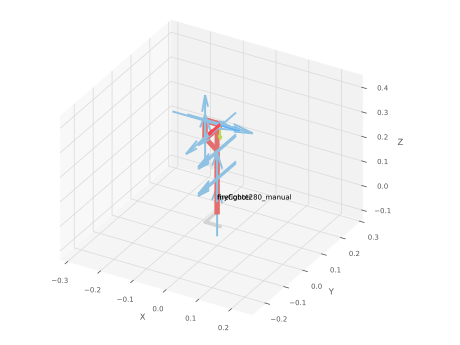

2

In [14]:
home = [0, 0, 0, 0, 0, 0]

robot_fig = manual_robot.plot(home, backend="pyplot")
robot_fig.add(urdf_robot)

**How it works**
- `robot.plot(q, backend="pyplot")` draws the robot at configuration `q` with Matplotlib and returns the plotting
  environment. `robot_fig.add(other_robot)` draws a second robot into the same scene (at its own `.q`, zeros here).
- **What differs:** both arms point straight up at $q = 0$ (that's what the offsets are for). The DH model draws its
  links along the DH frames, so its intermediate frames sit at different places (e.g. the DH frame 1 is on the
  shoulder axis, the URDF's `joint2` frame is where the CAD part starts). Only the end frames need to agree.
  Positions of intermediate frames and their axis directions differ, because DH forces x along the common normal and
  z along the joint axis, while the URDF author chose frames freely (`origin xyz/rpy`), exactly the Lab 1 remark.

---
## Task 12: Compare the end-effector transforms at home

In [15]:
home = [0, 0, 0, 0, 0, 0]
# Transform from the manual base to the manual tool frame
thome = manual_robot.fkine(home).A
print(thome)

# Transform from g_base to joint6_flange in the URDF-based model
urdf_home = urdf_robot.fkine(home, start='g_base', end='joint6_flange').A
print(urdf_home)

# Compare translation and orientation separately.
dp = urdf_home[:3, 3] - thome[:3, 3]                              # translation difference (m)
R_rel = thome[:3, :3].T @ urdf_home[:3, :3]                       # rotation from one frame to the other
angle = np.arccos(np.clip((np.trace(R_rel) - 1) / 2, -1, 1))      # its angle
print('position difference (mm):', dp * 1000, ' orientation difference (deg): %.4f' % np.degrees(angle))

[[-0.      0.      1.      0.0456]
 [-1.     -0.     -0.     -0.0634]
 [-0.     -1.      0.      0.4127]
 [ 0.      0.      0.      1.    ]]
[[ 0.     -0.      1.      0.0456]
 [-1.      0.      0.     -0.0636]
 [-0.     -1.     -0.      0.4181]
 [ 0.      0.      0.      1.    ]]
position difference (mm): [ 0.     -0.221   5.4698]  orientation difference (deg): 0.0003


**How it works**
- `fkine(q)` returns an `SE3`; `.A` is its 4×4 array.
- `fkine(q, start='g_base', end='joint6_flange')` names the two frames explicitly (for this URDF they are also the
  defaults: `base_link` and `ee_links[0]`).
- **Translation:** subtract the two last columns.
- **Orientation:** $R_{rel} = R_{manual}^T R_{urdf}$ is the rotation from one frame to the other.
  Its angle follows from $\operatorname{tr}(R) = 1 + 2\cos\vartheta$, so $\vartheta = \arccos\big((\operatorname{tr}R - 1)/2\big)$.
  `np.clip(x, -1, 1)` guards against rounding pushing the value to 1.0000000002, where `arccos` would return NaN.
- **Result:** the orientations agree (0.0003°, the offsets make the DH frame 6 point the same way as
  `joint6_flange`); the positions differ by 5.5 mm, almost all in z. That comes from the URDF's link lengths being
  slightly different from the handout's DH table (joint-1 height 0.13956 m in the URDF vs $d_1$ = 0.13122 m in the
  table, minus a 1 mm offset in the next joint). So the DH model of the handout and the URDF are not exactly the same
  robot; this is the "small discrepancy from the modeling convention" that the task text mentions.

---
## Task 13: FK at a known configuration

In [16]:
q_test = [0, -np.pi/2, 0, 0, 0, 0]

t_manual = manual_robot.fkine(q_test).A
# Confirm the URDF chain runs from g_base to joint6_flange:
print("URDF base link:", urdf_robot.base_link)
print("URDF EE link:", urdf_robot.ee_links[0])
t_urdf = urdf_robot.fkine(q_test).A

print("Manual FK end-effector position (m):", t_manual[:3, 3])
print("URDF FK end-effector position (m):", t_urdf[:3, 3])
print("Position difference (mm):", np.linalg.norm(t_manual[:3, 3] - t_urdf[:3, 3]) * 1000)

URDF base link: Link("g_base")
URDF EE link: Link("joint6_flange", SE3(0, 0.0456, 0; -90°, -0°, 0°) ⊕ Rz(q), parent="joint6", qlim=[-3.14, 3.14])
Manual FK end-effector position (m): [ 0.2814 -0.0634  0.0856]
URDF FK end-effector position (m): [ 0.2796 -0.0636  0.093 ]
Position difference (mm): 7.577249015871109


**How it works / sanity check by hand**
- $q_2 = -\pi/2$ tips the upper arm over to horizontal, so the arm reaches out along x. Reading the DH table:
  - $x = |a_2| + |a_3| + d_5 = 0.1104 + 0.096 + 0.07505 = 0.28145$ m (printed: 0.2814),
  - $y = -d_4 = -0.0634$ m, the sideways offset of the wrist (printed: −0.0634),
  - $z = d_1 - d_6 = 0.13122 - 0.0456 = 0.0856$ m, because the flange now points down by $d_6$ (printed: 0.0856).
  So the manual model can be checked by hand.
- The URDF result is close; the remaining 7.6 mm come almost entirely from the URDF's joint-1 height
  (0.13956 m instead of $d_1$ = 0.13122 m, ≈ 8 mm).

---
## Task 14: Relative transform between the two end-effector frames
$$H_d = H_{ee,manual}^{-1}\,H_{ee,urdf}$$

In [17]:
# determine the transform between the manual tool frame and joint6_flange
delta = np.linalg.inv(thome) @ urdf_home
print(delta)

[[ 1.     -0.     -0.      0.0002]
 [ 0.      1.      0.     -0.0055]
 [ 0.     -0.      1.      0.    ]
 [ 0.      0.      0.      1.    ]]


**How it works**
- `np.linalg.inv` inverts a matrix. $H_{manual}^{-1}H_{urdf}$ is "the pose of the URDF flange frame, seen from the
  manual tool frame". If both frames coincided it would be the identity.
- For a transform, $H^{-1} = \begin{bmatrix}R^T & -R^T t\\ 0 & 1\end{bmatrix}$; `np.linalg.inv` gives the same
  result (spatialmath's `SE3(...).inv()` uses this formula directly).

In [18]:
# convert the relative transform to RPY angles: roll, pitch, yaw
euldelta = tr2rpy(delta, order='zyx')

print(euldelta)

[-0. -0.  0.]


**Interpretation**
- `tr2rpy(T, order='zyx')` returns `[roll, pitch, yaw]` with $R = R_z(\text{yaw})R_y(\text{pitch})R_x(\text{roll})$
  (see Lab 1, Task 24).
- The angles are ≈ 0: with the offsets from Table 2, the DH end frame already has the same axis directions as
  `joint6_flange` (x, y, z point the same way). Had the DH end frame been, say, rotated 90° about z, you would see
  yaw = ±90° here: that would mean "the DH x-axis is the URDF y-axis".
- What remains is a small translation (a few mm), which is a length difference, not an axis convention.

**Example: in degrees, plus the leftover translation**

```python
print('rpy (deg):', np.degrees(euldelta))
print('translation (mm):', delta[:3, 3] * 1000)
```

Output:
```text
rpy (deg): [-0.0002 -0.      0.0002]
translation (mm): [ 0.221  -5.4698  0.    ]
```


---
## Task 15: Compensate the discrepancy with the tool transform

In [20]:
# apply the correction to the manual end-effector frame
manual_robot.tool = manual_tool * SE3(trnorm(delta))
# thome after orientation compensation
thome = manual_robot.fkine(home).A
print(thome)

[[ 0.     -0.      1.      0.0456]
 [-1.      0.      0.     -0.0636]
 [-0.     -1.     -0.      0.4181]
 [ 0.      0.      0.      1.    ]]


**How it works**
- New tool = old tool followed by `delta`. For `SE3` objects `*` means **composition** (matrix product), not
  element-wise multiplication.
- `trnorm(delta)` (spatialmath) re-orthonormalises the rotation part. After `inv` and `@` in floating point the
  matrix can be off by ~1e-16, and `SE3(...)` checks that its input is a valid rotation. `trnorm` removes the doubt.
- Setting the attribute `manual_robot.tool = ...` changes the model in place; the next `fkine` uses it.
- Now base·A1…A6·tool = URDF flange at home, by construction.

---
## Task 16: Compare both models again

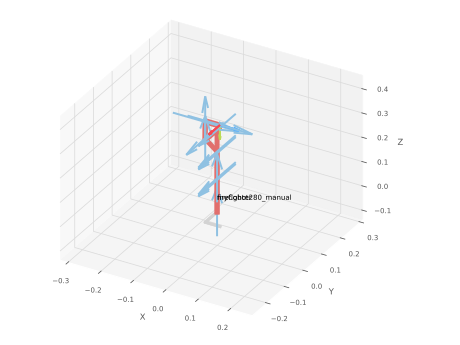

The manual myCobot 280 model and the URDF model agree at the end effector.


In [21]:
home = [0, 0, 0, 0, 0, 0]

robot_2 = manual_robot.plot(home, backend="pyplot")
robot_2.add(urdf_robot)

if np.linalg.norm(thome - urdf_home) < 1.0e-7:
    print('The manual myCobot 280 model and the URDF model agree at the end effector.')
else:
    print('The manual myCobot 280 model and the URDF model still differ at the end effector.')

**How it works**
- `np.linalg.norm(A - B)` of a matrix is the Frobenius norm: the square root of the sum of all squared element
  differences. Below 1e-7 means identical up to rounding.
- They agree at home because the tool correction was computed **at** home. Whether the models agree **everywhere**
  is tested next.
- From here on the URDF model is the reference, because the controller (`mycobot_control`) uses it.

---
## Task 17: A random configuration

The manual myCobot 280 model and the URDF model do not fully agree at the end effector.


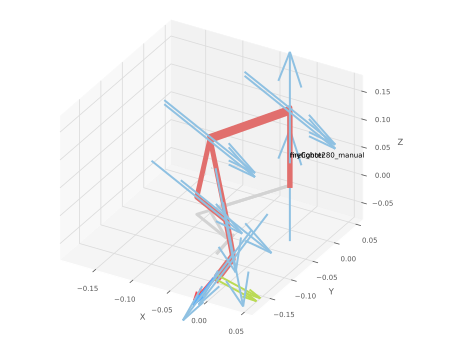

2

In [22]:
# generate a random myCobot 280 configuration
randq = urdf_robot.random_q()

# reuse the same joint vector for both models
urdf_randq = randq

# Transform from base to end effector
trandq = manual_robot.fkine(randq).A
# Compute the corresponding URDF-model end-effector transform for the same joint vector
urdf_trandq = urdf_robot.fkine(urdf_randq).A

if np.linalg.norm(trandq - urdf_trandq) < 1.0e-7:
    print('The manual myCobot 280 model and the URDF model agree at the end effector.')
else:
    print('The manual myCobot 280 model and the URDF model do not fully agree at the end effector.')

# Plot
robot_3 = urdf_robot.plot(urdf_randq, backend="pyplot")
manual_robot.q = randq
robot_3.add(manual_robot)

**How it works**
- `random_q()` draws one random value per joint, uniformly between that joint's limits (`urdf_robot.qlim`).
- Every run draws a new configuration, so the numbers in the example below change from run to run (the conclusion does not).
- `robot.q = ...` sets the configuration that `add()` will draw.
- **Result:** the orientations agree (all joint axes match), the positions differ by ~1 cm. The one-time tool correction cannot fix that, because the error comes from **link lengths inside the
  chain** (joint 1 height, joint 4/5 offsets) and so changes with $q$. A base/tool correction only removes errors at
  the two ends of the chain.
- If the handout's DH table and the URDF had the same lengths, the two models would agree for every $q$ (up to
  rounding). The leftover difference tells you that some link lengths disagree; here mainly the joint-1 height
  (about 8 mm) and small joint offsets. Which model describes the *real* robot better is a question for a measurement
  (Lab 5 uses measured poses); ask the TAs which one the controller is calibrated against (it uses the URDF).

**Example: how large is the difference?**

```python
print('randq (deg):', np.degrees(randq))
dp = (urdf_trandq[:3, 3] - trandq[:3, 3]) * 1000
R_rel = trandq[:3, :3].T @ urdf_trandq[:3, :3]
print('position difference (mm):', dp, ' orientation difference (deg): %.4f' % np.degrees(np.arccos(np.clip((np.trace(R_rel) - 1) / 2, -1, 1))))
```

Output:
```text
randq (deg): [  61.9104   93.1321   76.3678   18.4437  -33.9744 -121.6775]
position difference (mm): [4.9793 0.4624 6.9016]  orientation difference (deg): 0.0008
```


---
## ROS 2 integration (Tasks 18–29)
**Where this runs:** the controller `mycobot_control` runs on the robot's Pi (it owns the serial port). The notebook
talks to it through ROS 2 topics, either in Jupyter on the Pi (see the README "Robot Pi" section) or on a laptop in
the same network and `ROS_DOMAIN_ID`.

**These cells were not executed for the saved version.** They need the running controller.

**Safety:** `/mycobot/joint_command` goes straight to the servos as one `send_angles` at speed 50. There is no
step limit. So: start from the measured pose, change little, and check the target first (`check_joint_target_rad`
below). All motion cells default to off.

## Task 18: Launch the controller
In a terminal on the Pi (serial notebook closed first, see Lab 7):
```bash
source ~/venvs/mycobot/bin/activate
source ~/mycobot-project/ros2_ws/install/setup.bash
ros2 launch mycobot_control mycobot_control.launch.py
```
- `ros2 launch <package> <launch file>` starts the node(s) described in the launch file, here one node with its
  parameters (port `/dev/serial0`, baud 1 000 000, speeds, IK settings). Keep this terminal open; Ctrl+C stops it.
- The workspace `setup.bash` must be sourced, or ROS can't find the `mycobot_control` package.

## Task 19: Inspect the interfaces
```bash
ros2 topic list                                  # all topics currently known
ros2 topic info /mycobot/joint_states            # type + number of publishers/subscribers
ros2 topic info /mycobot/joint_command
ros2 topic info /mycobot/joint_velocity
ros2 topic info /mycobot/ee_pose
ros2 interface show sensor_msgs/msg/JointState   # fields of a message type
ros2 interface show std_msgs/msg/Float64MultiArray
```
What you should see:
- `/mycobot/joint_states`: `sensor_msgs/msg/JointState`, **1 publisher** (the controller).
- the three command topics: `std_msgs/msg/Float64MultiArray`, **1 subscriber** each (the controller), 0 publishers
  until your notebook creates one.
- `JointState` has `header` (time stamp + frame), `name[]`, `position[]`, `velocity[]`, `effort[]`;
  `Float64MultiArray` has a `layout` (can stay empty) and `data[]` (a list of floats).

## Task 20: RViz2
Follow the template steps (Fixed Frame `g_base`, RobotModel from file, TF). Two things to know:
- The controller publishes joint names `joint1 … joint6`, while the URDF's joints are named
  `joint2_to_joint1 …`. RViz's RobotModel needs TF frames, which normally come from `robot_state_publisher`; if the
  model stays grey with "No transform" errors, ask the TAs which launch file publishes TF for this setup.
- RViz needs a display: run it on the laptop, not on the Pi (1.8 GB RAM, no screen).

---
## Task 21: State topic and command topics

In [ ]:
import time

import rclpy
from rclpy.node import Node
from sensor_msgs.msg import JointState
from std_msgs.msg import Float64MultiArray


class MyCobotNotebookNode(Node):
    def __init__(self):
        super().__init__('mycobot_fk_notebook')
        self.last_joint_state = None
        self.joint_state_sub = self.create_subscription(
            JointState,
            '/mycobot/joint_states',
            self.joint_state_callback,
            10,
        )

    def joint_state_callback(self, msg):
        self.last_joint_state = msg

**How it works (given code, explained)**
- `class MyCobotNotebookNode(Node):` defines a new class that **inherits** from `rclpy.node.Node`, so it has all the
  ROS abilities (publishers, subscriptions, timers, logging).
- `def __init__(self):` is the constructor, run when you write `MyCobotNotebookNode()`. `self` is the object itself.
- `super().__init__('mycobot_fk_notebook')` runs the parent class constructor and gives the node its name
  (visible in `ros2 node list`).
- `self.create_subscription(JointState, '/mycobot/joint_states', self.joint_state_callback, 10)`:
  message type, topic name, the function to call for every message, and the queue depth (QoS history: keep up to
  10 unprocessed messages).
- The callback just stores the newest message in `self.last_joint_state`. It only runs while the node is being
  **spun** (Task 22).
- Units on the topics: `JointState.position` in **radians**, `joint_command` in radians, `joint_velocity` in rad/s,
  `ee_pose` as `[x_mm, y_mm, z_mm, roll_deg, pitch_deg, yaw_deg]`.

---
## Task 22: Initialize rclpy and create the node

In [ ]:
if not rclpy.ok():
    rclpy.init(args=None)

node = MyCobotNotebookNode()

**How it works**
- `rclpy.init()` starts the ROS 2 client library in this Python process. It may only be called once; `rclpy.ok()`
  is `True` after init, so the `if` makes the cell safe to re-run.
- `MyCobotNotebookNode()` creates the node (and with it the subscription).

---
## Task 23: Available topics and one joint state

In [ ]:
# Terminal commands (the leading ! runs a shell command from the notebook)
# !ros2 topic list
# !ros2 topic echo /mycobot/joint_states --once

rclpy.spin_once(node, timeout_sec=0.5)
print(node.last_joint_state)

**How it works**
- `rclpy.spin_once(node, timeout_sec=0.5)` processes **at most one** waiting event (e.g. one incoming message →
  one callback), waiting up to 0.5 s. A normal ROS program calls `rclpy.spin(node)`, which never returns; in a
  notebook you spin once whenever you want fresh data.
- If it prints `None`, no message arrived in time: controller not running, wrong `ROS_DOMAIN_ID`, or you need to
  spin again (the state is published at 5 Hz).
- `!command` in a notebook cell runs a shell command.

---
## Task 24: Publisher for joint commands

In [ ]:
joint_command_publisher = node.create_publisher(
    Float64MultiArray,
    '/mycobot/joint_command',
    10,
)

- `create_publisher(type, topic, qos_depth)` mirrors `create_subscription` without a callback. Never publish on
  `/mycobot/joint_states`: the controller owns that topic.

---
## Task 25: Empty command message

In [ ]:
joint_command_msg = Float64MultiArray()
print(joint_command_msg)

- A ROS message is a Python object; calling the class creates an empty one. Printing shows the fields:
  `layout` (dimension info, can stay empty for a flat list) and `data=[]`.

---
## Task 26: A joint vector in the message
**Safe choice:** start from the **measured** pose and move joint 1 by +10°. (The template suggests `randq`: a
random pose can be far away and the robot would jump there at speed 50. Don't.)

In [ ]:
rclpy.spin_once(node, timeout_sec=0.5)
q_now = np.array(node.last_joint_state.position, dtype=float)    # measured pose (rad)
q_cmd = q_now + np.radians([10, 0, 0, 0, 0, 0])                  # joint 1 + 10 deg, others unchanged
assert np.all(np.abs(q_cmd - q_now) <= np.radians(15)), 'a joint moves more than 15 deg'
joint_command_msg.data = q_cmd.tolist()

**How it works**
- `rclpy.spin_once(node, timeout_sec=0.5)` lets the node process the waiting `joint_states` message (Task 23), so
  `node.last_joint_state` holds the latest measured state. `np.array(msg.position, dtype=float)` turns the sequence into a
  NumPy array of radians.
- `np.radians([10, 0, 0, 0, 0, 0])` converts the offsets from degrees to radians; adding them to `q_now` moves joint 1
  by +10° from where it is now, the others stay.
- `assert condition, "message"` stops with an `AssertionError` and the message if the condition is `False`. Here:
  `np.abs(...)` takes the step of every joint, `<= np.radians(15)` compares each with 15°, `np.all(...)` needs every
  joint to pass. A bad target raises an error **before** anything is sent.
- `.tolist()`: `.data` of `Float64MultiArray` must be a list of Python floats.
- Nothing is published here. Task 28 does that.


---
## Task 27: Observed joint state

In [ ]:
rclpy.spin_once(node, timeout_sec=0.5)
print(node.last_joint_state)

- `/mycobot/joint_states` = what the robot **reports** (measured or estimated by the controller);
  `/mycobot/joint_command` = what you **ask** for. They only match after the motion has finished.

---
## Task 28: Publish the joint command

In [ ]:
send_motion = False   # a person sets this to True after checking the target of Task 26 and the workspace

if send_motion:
    joint_command_publisher.publish(joint_command_msg)

- `publisher.publish(msg)` hands the message to ROS; the controller's callback converts radians → degrees and
  calls `send_angles` once.
- Spin + print again (Task 27) a few seconds later to see the robot arrive.

---
## Task 29: Linearly interpolated joint trajectory
$$ q_t = q_i + (q_f - q_i)\,\frac{t}{t_f} $$

**First, offline (no robot):** what the loop computes, for a small motion from a parked pose.

```python
qi_demo = np.radians([7.2, -99.31, -70.92, 81.38, 90.08, -74.26])   # parked pose read in Lab 7
qf_demo = qi_demo + np.radians([15, 10, -10, 0, 0, 0])
t_f = 4.0
t = np.arange(0, t_f + 1e-9, 0.05)                 # 20 Hz samples, including t_f
tau = np.clip(t / t_f, 0.0, 1.0)
q_samples = qi_demo + np.outer(tau, qf_demo - qi_demo)   # shape (len(t), 6)
print(q_samples.shape)
print(np.degrees(q_samples[[0, 40, 80]]))   # start, halfway, end
```

Output:
```text
(81, 6)
[[  7.2  -99.31 -70.92  81.38  90.08 -74.26]
 [ 14.7  -94.31 -75.92  81.38  90.08 -74.26]
 [ 22.2  -89.31 -80.92  81.38  90.08 -74.26]]
```


**How it works**
- `tau = t / t_f` runs from 0 to 1; `np.clip` keeps it inside [0, 1] even if the loop overshoots `t_f` a little.
- `np.outer(tau, dq)` is the outer product: row *k* = `tau[k] * dq`. Adding `qi` (broadcast to every row) gives all
  samples at once, the vectorised form of the loop formula.
- Every angle grows linearly with time, i.e. **constant velocity** that starts and stops instantly (infinite acceleration). Lab 6
  replaces this with trapezoidal profiles.

**Now the loop for the robot:** the template's loop with the gaps filled. Three lines differ from the template, each
marked in the code: `publish_ros2 = False` (a person turns it on), the start `qi` is the **measured** pose instead of zeros
(the arm would first jump to the all-zero pose), and `qf` is a small move instead of up to 90° per joint.


In [ ]:
go_into_loop = True

publish_ros2 = False   # a person sets this to True after checking the printed target (template: True)

if go_into_loop:
    rate_hz = 20.0
    dt = 1.0 / rate_hz
    max_time = 4.0

    # prepare loop
    # /mycobot/joint_command expects joint angles in radians
    rclpy.spin_once(node, timeout_sec=0.5)
    qi = np.array(node.last_joint_state.position, dtype=float)    # start at the measured pose (template: zeros)
    qf = qi + np.radians([15, 10, -10, 0, 0, 0])                  # small move (template: up to 90 deg per joint)
    start_time = time.time()
    current_time = time.time()

    while current_time - start_time < max_time:
        current_time = time.time()
        tau = min((current_time - start_time) / max_time, 1.0)
        qinterp = qi + (qf - qi) * tau

        if publish_ros2:
            joint_command_msg.data = qinterp.tolist()
            joint_command_publisher.publish(joint_command_msg)
            rclpy.spin_once(node, timeout_sec=0.0)

        time.sleep(dt)

# Optional cleanup at the end of the notebook:
# node.destroy_node()
# rclpy.shutdown()

**How it works**
- `time.time()` is the wall-clock time in seconds; `current_time - start_time` is the elapsed time $t$.
- `while elapsed < max_time:` loops for 4 s; `time.sleep(dt)` waits 50 ms, giving about 20 commands per second.
- `min(..., 1.0)` caps `tau` so the last command is exactly `qf`.
- `qi + (qf - qi) * tau` is the formula; `.tolist()` converts it for the message.
- `spin_once(node, timeout_sec=0.0)` handles pending callbacks without waiting, so `last_joint_state` stays fresh
  while you publish.
- Each message becomes one `send_angles` at the controller's fixed speed; many small steps approximate a smooth
  motion.
- `node.destroy_node()` / `rclpy.shutdown()` free the ROS resources when you are done.

---
## Summary
- DH: four parameters per joint, $A_i = T_z(d_i)R_z(\theta_i)T_x(a_i)R_x(\alpha_i)$, FK = base · $A_1 \cdots A_6$ · tool.
- URDF: per joint a fixed origin (xyz, rpy) followed by a rotation about the joint axis. Same robot, different
  bookkeeping.
- Constant differences at the ends of the chain → base/tool correction. Differences that change with $q$ → link
  lengths/axes inside the chain.
- ROS: node → subscription (state, radians) + publisher (commands, radians); `spin_once` in notebooks; every motion
  command is checked first and switched on by a person.